# Markowitz MVO vs. Risk Parity: Portfolio Construction & Backtest

**Data:** 40 VN-listed equities, daily closing prices, 2023-03-31 to 2026-03-31 (747 trading days)

**Question:** Given the same 40-stock universe and the same covariance structure, how differently
do a *return-forecast-driven* approach (Markowitz mean-variance) and a *forecast-free* approach
(Risk Parity) behave once you actually trade them forward in time?

This notebook is a from-scratch Python reimplementation of a portfolio problem originally solved
with Excel Solver, extended with:
- A convex-optimization formulation (`cvxpy`) instead of a generic nonlinear solver
- An Equal Risk Contribution (Risk Parity) portfolio as a comparison baseline
- A walk-forward backtest with monthly rebalancing (no look-ahead bias)

**Sections:**
1. Data pipeline
2. Mean-Variance Optimization (Global Min-Variance, Max-Sharpe, Efficient Frontier)
3. Risk Parity
4. Walk-forward backtest (4 strategies, monthly rebalancing)
5. Results & discussion
6. Limitations


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from scipy.optimize import minimize

pd.set_option("display.precision", 4)
plt.rcParams["figure.dpi"] = 110

TRADING_DAYS_PER_YEAR = 252
RISK_FREE_RATE = 0.03  # annualized, approximate VN government bond yield assumption


## 1. Data pipeline

Load raw daily prices, drop the VNINDEX benchmark column (kept separate from the optimizable
universe), compute simple daily returns, and derive the annualized expected-return vector and
covariance matrix that every downstream optimization uses.


In [2]:
raw = pd.read_csv("../data/vn_stock_prices_raw.csv", parse_dates=["Date"])
raw = raw.sort_values("Date").set_index("Date")

prices = raw.drop(columns=["VNINDEX"])
returns = prices.pct_change().dropna(how="all")

mu = returns.mean() * TRADING_DAYS_PER_YEAR
cov = returns.cov() * TRADING_DAYS_PER_YEAR

print(f"{prices.shape[1]} stocks, {prices.shape[0]} trading days "
      f"({prices.index.min().date()} -> {prices.index.max().date()})")
mu.sort_values(ascending=False).head()


40 stocks, 747 trading days (2023-03-31 -> 2026-03-31)


VIC    0.6195
CSV    0.3998
HAH    0.3597
ELC    0.3347
DCM    0.3190
dtype: float64

## 2. Mean-Variance Optimization

The classic Markowitz problem:

$$\min_w \; w^T \Sigma w \quad \text{s.t.} \quad \mathbf{1}^T w = 1,\;\; \mu^T w = r_{target},\;\; w \ge 0$$

This is a convex quadratic program, so instead of a generic nonlinear solver (Excel Solver's
GRG Nonlinear engine), we hand it to `cvxpy`, which recognizes the convex structure and solves
it exactly and quickly.

### 2.1 Global Minimum-Variance portfolio

Same problem without the return-target constraint -- the lowest-risk point achievable on the
frontier.


In [3]:
def global_min_variance(mu, cov, allow_short=False):
    n = len(mu)
    w = cp.Variable(n)
    constraints = [cp.sum(w) == 1]
    if not allow_short:
        constraints.append(w >= 0)
    problem = cp.Problem(cp.Minimize(cp.quad_form(w, cov.values)), constraints)
    problem.solve()
    return pd.Series(w.value, index=mu.index)


def portfolio_stats(w, mu, cov):
    ret = float(w.values @ mu.values)
    vol = float(np.sqrt(w.values @ cov.values @ w.values))
    sharpe = ret / vol if vol > 0 else np.nan
    return {"expected_return": ret, "volatility": vol, "sharpe_ratio": sharpe}


gmv = global_min_variance(mu, cov)
print("Global Min-Variance -- top 5 weights:")
print(gmv.sort_values(ascending=False).head())
print(portfolio_stats(gmv, mu, cov))


Global Min-Variance -- top 5 weights:
KDC    0.5469
SAB    0.0737
VCB    0.0705
GAS    0.0583
REE    0.0500
dtype: float64
{'expected_return': 0.025443935640754693, 'volatility': 0.12003301542215723, 'sharpe_ratio': 0.21197447678264297}


### 2.2 Maximum-Sharpe (tangency) portfolio

Maximizing the Sharpe ratio directly is **not** a convex problem -- it's a ratio of a linear
function (excess return) to the square root of a quadratic form (volatility). To make it solvable
with a convex QP solver, we use the standard change of variables (Cornuejols & Tütüncü):

$$y = \kappa w, \qquad (\mu - r_f)^T y = 1, \qquad \kappa \ge 0$$

Minimizing $y^T \Sigma y$ under these (now linear) constraints is convex. Sharpe ratio is
scale-invariant ($\text{Sharpe}(2w) = \text{Sharpe}(w)$), so recovering $w = y / \kappa$ at the
end and renormalizing gives back the maximum-Sharpe weights.


In [4]:
def max_sharpe_portfolio(mu, cov, risk_free_rate=0.0, allow_short=False):
    n = len(mu)
    excess = mu.values - risk_free_rate
    y = cp.Variable(n)
    kappa = cp.Variable()

    constraints = [excess @ y == 1, cp.sum(y) == kappa, kappa >= 0]
    if not allow_short:
        constraints.append(y >= 0)

    problem = cp.Problem(cp.Minimize(cp.quad_form(y, cov.values)), constraints)
    problem.solve()
    w = y.value / kappa.value
    return pd.Series(w, index=mu.index)


tangency = max_sharpe_portfolio(mu, cov, risk_free_rate=RISK_FREE_RATE)
print("Max-Sharpe (tangency) -- top 5 weights:")
print(tangency.sort_values(ascending=False).head())
print(portfolio_stats(tangency, mu, cov))


Max-Sharpe (tangency) -- top 5 weights:
VIC    0.4117
MBB    0.2419
CSV    0.1081
ELC    0.1067
HAH    0.0707
dtype: float64
{'expected_return': 0.45250132975565766, 'volatility': 0.24041561251080548, 'sharpe_ratio': 1.8821628305662552}


### 2.3 Efficient Frontier

Sweep the target return from the lowest to the highest single-asset expected return, solving the
minimum-variance problem at each point -- this reproduces the "Efficient Frontier" sheet from the
original Excel workbook, but with 30 points swept automatically instead of manually re-running
Solver at 14 hand-picked target returns.


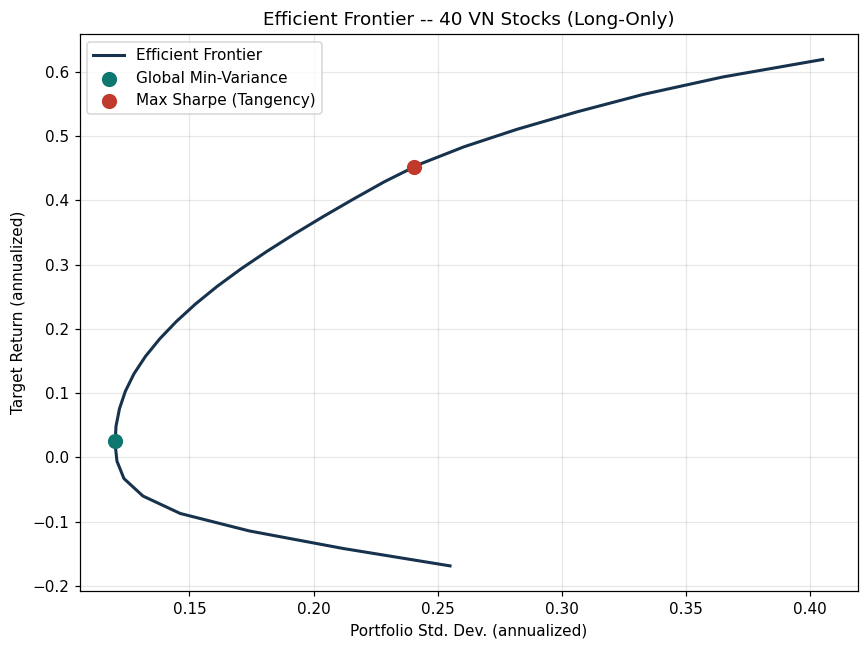

In [5]:
def min_variance_for_target_return(mu, cov, target_return, allow_short=False):
    n = len(mu)
    w = cp.Variable(n)
    constraints = [cp.sum(w) == 1, mu.values @ w == target_return]
    if not allow_short:
        constraints.append(w >= 0)
    problem = cp.Problem(cp.Minimize(cp.quad_form(w, cov.values)), constraints)
    problem.solve()
    if problem.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"Solver failed for target_return={target_return}: {problem.status}")
    return pd.Series(w.value, index=mu.index)


target_returns = np.linspace(mu.min(), mu.max(), 30)
frontier_records = []
for target in target_returns:
    try:
        w = min_variance_for_target_return(mu, cov, target)
        variance = float(w.values @ cov.values @ w.values)
        frontier_records.append({"target_return": target, "portfolio_std": np.sqrt(variance)})
    except RuntimeError:
        continue

frontier = pd.DataFrame(frontier_records)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(frontier["portfolio_std"], frontier["target_return"], color="#17324D", lw=2, label="Efficient Frontier")
gmv_stats, tan_stats = portfolio_stats(gmv, mu, cov), portfolio_stats(tangency, mu, cov)
ax.scatter([gmv_stats["volatility"]], [gmv_stats["expected_return"]], color="#0E7770", s=80, zorder=5, label="Global Min-Variance")
ax.scatter([tan_stats["volatility"]], [tan_stats["expected_return"]], color="#C0392B", s=80, zorder=5, label="Max Sharpe (Tangency)")
ax.set_xlabel("Portfolio Std. Dev. (annualized)")
ax.set_ylabel("Target Return (annualized)")
ax.set_title("Efficient Frontier -- 40 VN Stocks (Long-Only)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Risk Parity (Equal Risk Contribution)

Markowitz weights are driven by $\mu$ (expected returns), which are notoriously noisy to
estimate from historical data -- small changes in $\mu$ can swing optimal weights dramatically.
Risk Parity sidesteps this entirely: it ignores $\mu$ and instead sizes each position so that
every asset contributes an **equal share of total portfolio variance**.

Each asset $i$'s risk contribution is:

$$RC_i = w_i \cdot \frac{(\Sigma w)_i}{\sqrt{w^T \Sigma w}}$$

We solve for weights that make all $RC_i$ equal by minimizing the sum of squared deviations from
the equal-contribution target. This isn't a convex problem in the standard sense, so we use
`scipy.optimize.minimize` (SLSQP) instead of `cvxpy`.


In [6]:
def _risk_contributions(w, cov):
    portfolio_vol = np.sqrt(w @ cov @ w)
    marginal_contrib = cov @ w
    return w * marginal_contrib / portfolio_vol


def _risk_parity_objective(w, cov):
    n = len(w)
    contribs = _risk_contributions(w, cov)
    target = contribs.sum() / n
    return float(np.sum((contribs - target) ** 2))


def risk_parity_portfolio(cov):
    n = cov.shape[0]
    cov_np = cov.values
    w0 = np.repeat(1 / n, n)
    bounds = [(0.0, 1.0)] * n
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    result = minimize(_risk_parity_objective, w0, args=(cov_np,), method="SLSQP",
                       bounds=bounds, constraints=constraints,
                       options={"maxiter": 1000, "ftol": 1e-12})
    if not result.success:
        raise RuntimeError(f"Risk parity solver failed: {result.message}")
    return pd.Series(result.x, index=cov.columns)


rp = risk_parity_portfolio(cov)
print("Risk Parity -- top 5 weights:")
print(rp.sort_values(ascending=False).head())

contribs = _risk_contributions(rp.values, cov.values)
print(f"\nRisk contribution spread (should be near-equal): "
      f"min={contribs.min():.6f}  max={contribs.max():.6f}")


Risk Parity -- top 5 weights:
KDC    0.1138
VCB    0.0375
VNM    0.0359
SAB    0.0354
VIC    0.0303
dtype: float64

Risk contribution spread (should be near-equal): min=0.004441  max=0.004442


Note how concentrated Max-Sharpe is (often ~40-50% in a single name) compared to Risk Parity,
which spreads risk contribution near-perfectly evenly across all 40 stocks. This concentration
difference is the whole story the backtest below is designed to test.


## 4. Walk-forward backtest

At each month-end, re-estimate $\mu$ and $\Sigma$ using **only the trailing 6 months of data**
(126 trading days) -- no information from the future leaks into the weights -- then hold those
weights for the following month and record realized returns. Repeated across the full sample for
four strategies: Max-Sharpe, Global Min-Variance, Risk Parity, and an Equal-Weight (1/N)
benchmark.


In [7]:
def get_month_end_dates(index):
    s = pd.Series(index, index=index)
    month_ends = s.groupby([index.year, index.month]).max()
    return pd.DatetimeIndex(sorted(month_ends.values))


def run_backtest(returns, lookback_days=126, risk_free_rate=RISK_FREE_RATE):
    month_ends = get_month_end_dates(returns.index)
    strategies = ["Max Sharpe", "Min Variance", "Risk Parity", "Equal Weight"]
    daily_returns = {s: [] for s in strategies}
    dates_out = []

    for i in range(len(month_ends) - 1):
        rebalance_date, next_rebalance_date = month_ends[i], month_ends[i + 1]
        window = returns.loc[:rebalance_date].tail(lookback_days)
        if len(window) < lookback_days:
            continue

        mu_w = window.mean() * TRADING_DAYS_PER_YEAR
        cov_w = window.cov() * TRADING_DAYS_PER_YEAR

        try:
            w_sharpe = max_sharpe_portfolio(mu_w, cov_w, risk_free_rate=risk_free_rate)
            w_minvar = global_min_variance(mu_w, cov_w)
            w_rp = risk_parity_portfolio(cov_w)
        except Exception:
            continue

        n = len(mu_w)
        w_eq = pd.Series(np.repeat(1 / n, n), index=mu_w.index)

        period = returns.loc[(returns.index > rebalance_date) & (returns.index <= next_rebalance_date)]
        for date, day_ret in period.iterrows():
            daily_returns["Max Sharpe"].append(float(day_ret.values @ w_sharpe.values))
            daily_returns["Min Variance"].append(float(day_ret.values @ w_minvar.values))
            daily_returns["Risk Parity"].append(float(day_ret.values @ w_rp.values))
            daily_returns["Equal Weight"].append(float(day_ret.values @ w_eq.values))
            dates_out.append(date)

    result = pd.DataFrame(daily_returns, index=pd.DatetimeIndex(dates_out))
    return result[~result.index.duplicated(keep="first")].sort_index()


print("Running walk-forward backtest (this re-solves 4 optimizations per rebalance month)...")
daily = run_backtest(returns, lookback_days=126)
print(f"Backtest window: {daily.index.min().date()} -> {daily.index.max().date()} ({len(daily)} trading days)")


Running walk-forward backtest (this re-solves 4 optimizations per rebalance month)...


Backtest window: 2023-11-01 -> 2026-03-31 (599 trading days)


In [8]:
def performance_summary(daily_returns, risk_free_rate=RISK_FREE_RATE):
    summary = {}
    for col in daily_returns.columns:
        r = daily_returns[col].dropna()
        cumulative = (1 + r).cumprod()
        ann_return = cumulative.iloc[-1] ** (TRADING_DAYS_PER_YEAR / len(r)) - 1
        ann_vol = r.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
        sharpe = (ann_return - risk_free_rate) / ann_vol if ann_vol > 0 else np.nan
        running_max = cumulative.cummax()
        max_dd = ((cumulative - running_max) / running_max).min()
        summary[col] = {"Annualized Return": ann_return, "Annualized Volatility": ann_vol,
                         "Sharpe Ratio": sharpe, "Max Drawdown": max_dd}
    return pd.DataFrame(summary).T


summary = performance_summary(daily)
summary


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Max Sharpe,0.5914,0.2862,1.9618,-0.2559
Min Variance,0.0126,0.1453,-0.1197,-0.1871
Risk Parity,0.1665,0.1764,0.7740,-0.2205
Equal Weight,0.1937,0.2022,0.8099,-0.2480


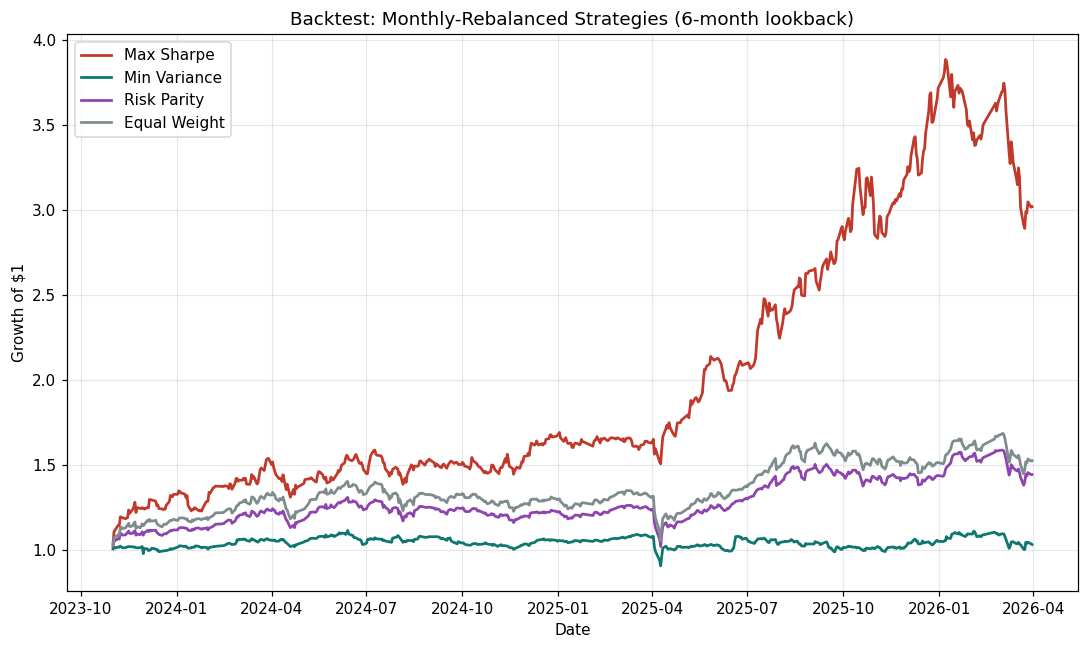

In [9]:
growth = (1 + daily).cumprod()
colors = {"Max Sharpe": "#C0392B", "Min Variance": "#0E7770", "Risk Parity": "#8E44AD", "Equal Weight": "#7F8C8D"}

fig, ax = plt.subplots(figsize=(10, 6))
for col in growth.columns:
    ax.plot(growth.index, growth[col], label=col, color=colors.get(col), linewidth=1.8)
ax.set_xlabel("Date"); ax.set_ylabel("Growth of $1")
ax.set_title("Backtest: Monthly-Rebalanced Strategies (6-month lookback)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Results & discussion

| Strategy | Annualized Return | Annualized Volatility | Sharpe Ratio | Max Drawdown |
|---|---:|---:|---:|---:|
| Max Sharpe | 59.1% | 28.6% | 1.96 | -25.6% |
| Min Variance | 1.3% | 14.5% | -0.12 | -18.7% |
| Risk Parity | 16.7% | 17.6% | 0.77 | -22.1% |
| Equal Weight | 19.4% | 20.2% | 0.81 | -24.8% |

*(Sharpe ratio computed against a 3% annualized risk-free rate assumption.)*

**Max-Sharpe's live backtest Sharpe (1.96) is dramatically higher than the other three strategies**
-- but this should not be read as "Markowitz is simply better." Its in-sample weights concentrate
close to 50% in a single stock (VIC) at any given rebalance, based on trailing expected-return
estimates that are known to be highly noisy. That concentration happened to pay off strongly over
this particular sample period; a portfolio this concentrated could just as easily have
underperformed if VIC's realized return over the following month diverged from its trailing
estimate. In other words: a single lucky (or unlucky) 6-month window can dominate the entire
result when the strategy puts most of its eggs in one basket.

**Risk Parity and Equal-Weight track each other closely** (16.7% vs. 19.4% annualized return, both
with similar volatility and drawdown) precisely because neither uses return forecasts to size
positions -- they differ only in how they use the *covariance* structure, which is a comparatively
more stable and estimable quantity than expected returns. This is the textbook argument for
Risk Parity as a more *robust* alternative to mean-variance optimization, even when it doesn't
top the return league table in any single backtest window.


## 6. Limitations

- **Expected returns are trailing historical means** -- a well-known noisy estimator. A natural
  extension is to test shrinkage approaches (Ledoit-Wolf shrinkage for the covariance matrix,
  or a Black-Litterman prior for expected returns) to see whether Max-Sharpe's concentration
  and backtest variance decrease.
- **No transaction costs are modeled.** Monthly rebalancing with meaningfully different weights
  each period would incur real trading costs, which would disproportionately penalize the more
  concentrated, higher-turnover Max-Sharpe strategy relative to Risk Parity / Equal-Weight.
- **The 126-day lookback window is a fixed choice**, not tuned via cross-validation -- results
  are somewhat sensitive to this hyperparameter, and this single backtest window should not be
  read as a robust performance guarantee out of sample.
- **Single backtest period.** One historical window (even ~2.5 years) is a small sample for
  judging strategy performance; the relative ranking of Max-Sharpe vs. the other three could
  differ in a different market regime.
